# Name :  Mayuri Mahesh Gade
## Assignement No 16

### KNN

### Step 1: Import Libraries

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

### Step 2: Load the Dataset

In [14]:
# Load the Zoo dataset
data = pd.read_csv('Zoo.csv')

In [15]:
# Display the first few rows of the dataset
print(data.head())

  animal name  hair  feathers  eggs  milk  airborne  aquatic  predator  \
0    aardvark     1         0     0     1         0        0         1   
1    antelope     1         0     0     1         0        0         0   
2        bass     0         0     1     0         0        1         1   
3        bear     1         0     0     1         0        0         1   
4        boar     1         0     0     1         0        0         1   

   toothed  backbone  breathes  venomous  fins  legs  tail  domestic  catsize  \
0        1         1         1         0     0     4     0         0        1   
1        1         1         1         0     0     4     1         0        1   
2        1         1         0         0     1     0     1         0        0   
3        1         1         1         0     0     4     0         0        1   
4        1         1         1         0     0     4     1         0        1   

   type  
0     1  
1     1  
2     4  
3     1  
4     1  


### Step 3: Data Preprocessing

In [16]:
# Check for missing values
print(data.isnull().sum())

animal name    0
hair           0
feathers       0
eggs           0
milk           0
airborne       0
aquatic        0
predator       0
toothed        0
backbone       0
breathes       0
venomous       0
fins           0
legs           0
tail           0
domestic       0
catsize        0
type           0
dtype: int64


In [17]:
# Separate features and the target variable
X = data.drop('type', axis=1)
y = data['type']

In [31]:
# Drop irrelevant columns (like 'animal_name' if it exists)
# Modify this line based on the actual column names in your dataset
X = data.drop(['animal_name', 'type'], axis=1, errors='ignore')

# Encode categorical columns using LabelEncoder (if applicable)
label_encoder = LabelEncoder()

# Apply LabelEncoder to all columns with categorical data
for col in X.select_dtypes(include=['object']).columns:
    X[col] = label_encoder.fit_transform(X[col])

# Target column (replace 'Type' with the actual name of the target column)
y = data['type']  # Or replace with the correct column name after checking


In [32]:
# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [33]:
# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

### Step 4: Implement KNN

In [34]:
# Initialize the KNN classifier with K=5
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')

In [37]:
# Train the classifier on the training set
knn.fit(X_train, y_train)
# Predict the labels for the test set
y_pred = knn.predict(X_test)

### Step 5: Evaluate the Model

In [38]:
# Print accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 95.24%


In [39]:
# Print the classification report
print('Classification Report:')
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        12
           2       1.00      1.00      1.00         2
           3       0.00      0.00      0.00         1
           4       0.67      1.00      0.80         2
           6       1.00      1.00      1.00         3
           7       1.00      1.00      1.00         1

    accuracy                           0.95        21
   macro avg       0.78      0.83      0.80        21
weighted avg       0.92      0.95      0.93        21



C:\Users\HP\AppData\Roaming\Python\Python38\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\HP\AppData\Roaming\Python\Python38\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\HP\AppData\Roaming\Python\Python38\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


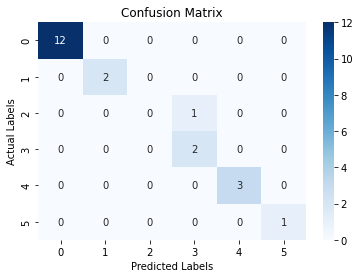

In [40]:
# Plot confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual Labels')
plt.xlabel('Predicted Labels')
plt.show()

# Interview Questions

Q1. What are the key hyperparameters in KNN?

Ans: 
- The key hyperparameters in K-Nearest Neighbors (KNN) are the number of neighbors (K) and the distance metric used to calculate proximity between data points. 
- The value of K determines how many nearest neighbors are considered when making predictions, and the distance metric defines how the distance between data points is calculated. 

- Elaboration:
    - Number of Neighbors (K):
        This hyperparameter controls the influence of neighboring data points on a prediction. A larger K value can lead to smoother decision boundaries and reduce the impact of outliers, but it may also cause underfitting. Conversely, a smaller K value can lead to more complex decision boundaries and potentially overfit the training data. 
    - Distance Metric:
        The distance metric determines how the distance between data points is calculated. Common metrics include Euclidean distance, Manhattan distance, and Minkowski distance. The choice of metric depends on the characteristics of the data and the problem being solved. 
    - Weights:
        In some KNN implementations, weights can be assigned to neighbors based on their distance. This allows closer neighbors to have a greater influence on the prediction than distant neighbors. 
    - Algorithm (e.g., brute force, k-d tree, ball tree):
        The algorithm used for searching the nearest neighbors can also be a hyperparameter, influencing computational efficiency. 
        For example, if you were using scikit-learn, you would typically tune n_neighbors (the number of neighbors) and potentially metric (the distance metric) using techniques like cross-validation or grid search. 

Q2. What distance metrics can be used in KNN?

Ans:
- In K-Nearest Neighbors (KNN), distance metrics are used to determine the similarity or dissimilarity between data points. Common metrics include Euclidean distance, Manhattan distance, and Minkowski distance. 
- Euclidean distance, the most popular, measures the straight-line distance, while Manhattan distance calculates the distance along the axes.
- Minkowski distance generalizes both, offering flexibility in choosing the distance parameter. 

    1. Euclidean Distance:
        - This is the most widely used metric in KNN. 
        - It calculates the straight-line distance between two points in Euclidean space. 
        - Formula: sqrt((x1 - y1)^2 + (x2 - y2)^2 + ... + (xn - yn)^2). 
        -  Suitable for continuous variables and is computationally straightforward. 
    2. Manhattan Distance:
        - Also known as L1 distance or taxicab distance. 
        - Calculates the sum of absolute differences between coordinates. 
        - Formula: |x1 - y1| + |x2 - y2| + ... + |xn - yn|. 
        - Useful when dealing with grid-like paths or discrete variables. 
    3. Minkowski Distance:
        - A generalization of both Euclidean and Manhattan distances. 
        - Defined as: (Σ|xi - yi|^p)^(1/p), where 'p' is the order of the distance. 
        - When p = 2, it becomes Euclidean distance, and when p = 1, it becomes Manhattan distance. 
        - Offers flexibility by adjusting the 'p' value for different scenarios. 